In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Better chart size
plt.rcParams["figure.figsize"] = (10,6)

In [7]:
df = pd.read_csv("data/processed/superstore_cleaned.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Day,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,8,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,8,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,12,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,11,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,11,7


In [9]:
df.shape

(9994, 27)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

# Business KPIs

In [11]:
total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_orders = df["Order ID"].nunique()

total_customers = df["Customer ID"].nunique()

average_order_value = total_sales / total_orders

print(f"Total Sales : ${total_sales:,.2f}")
print(f"Total Profit : ${total_profit:,.2f}")
print(f"Total Orders : {total_orders}")
print(f"Total Customers : {total_customers}")
print(f"Average Order Value : ${average_order_value:,.2f}")

Total Sales : $2,297,200.86
Total Profit : $286,397.02
Total Orders : 5009
Total Customers : 793
Average Order Value : $458.61


# Sales by Category

In [12]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

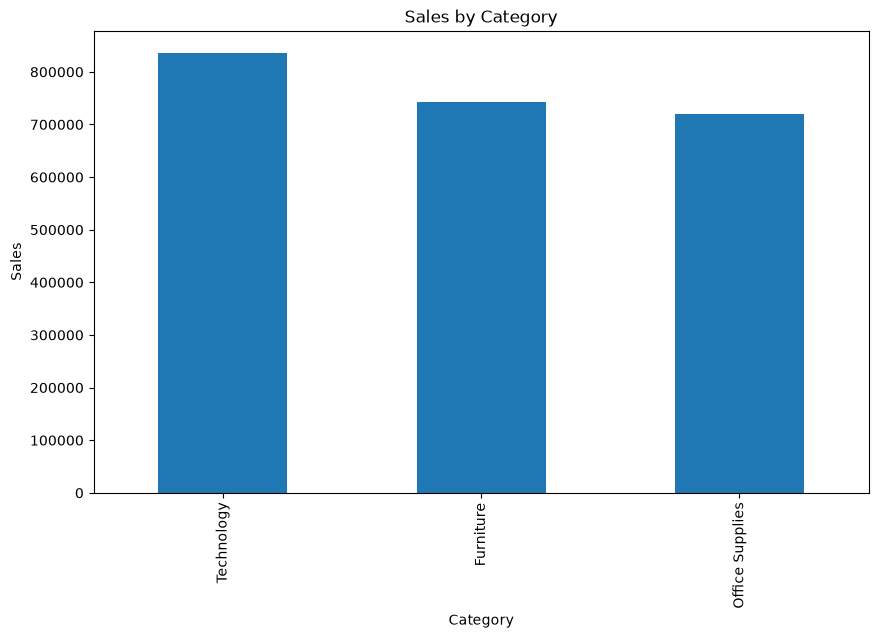

In [14]:
category_sales.plot(kind="bar")

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()

### Business Insight

Technology contributes the highest sales among all categories, indicating strong customer demand.

# Profit by Category

In [15]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

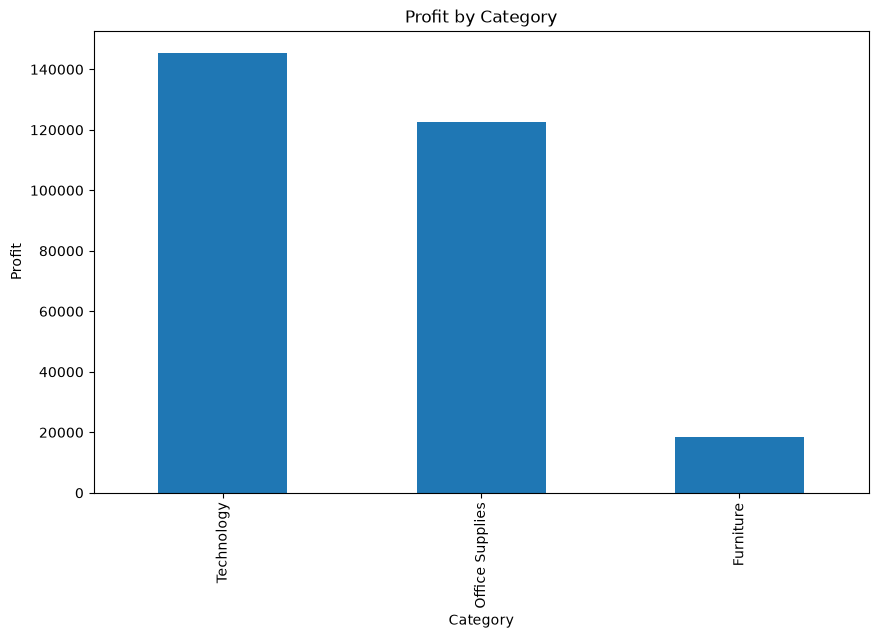

In [16]:
category_profit.plot(kind="bar")

plt.title("Profit by Category")

plt.xlabel("Category")

plt.ylabel("Profit")

plt.show()

# Sales by Region

In [17]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

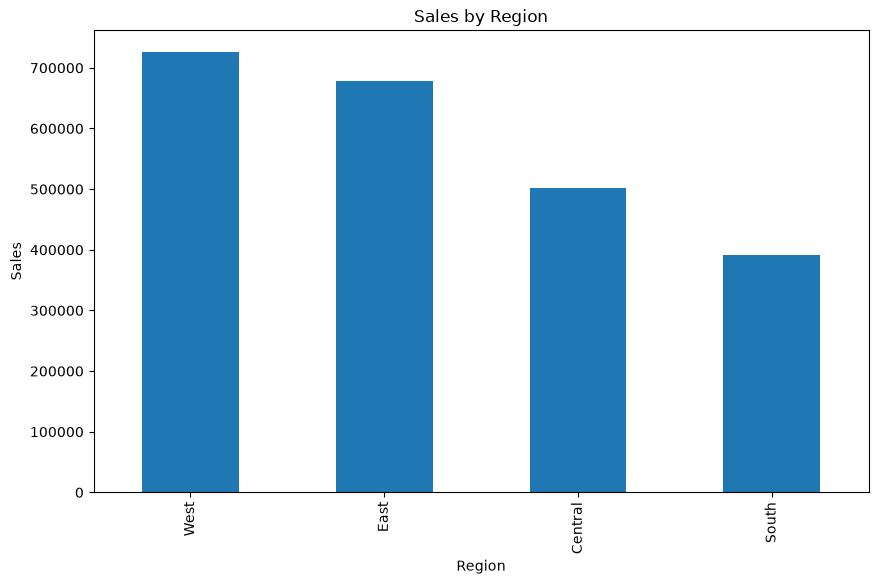

In [18]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

# Customer Segment Analysis

In [19]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

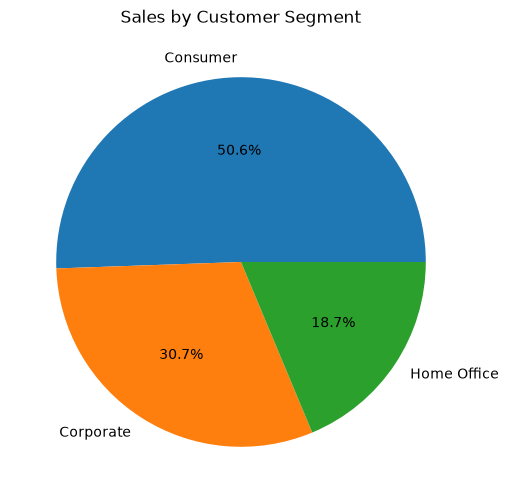

In [20]:
segment_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Sales by Customer Segment")

plt.show()

# Top 10 Products

In [21]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

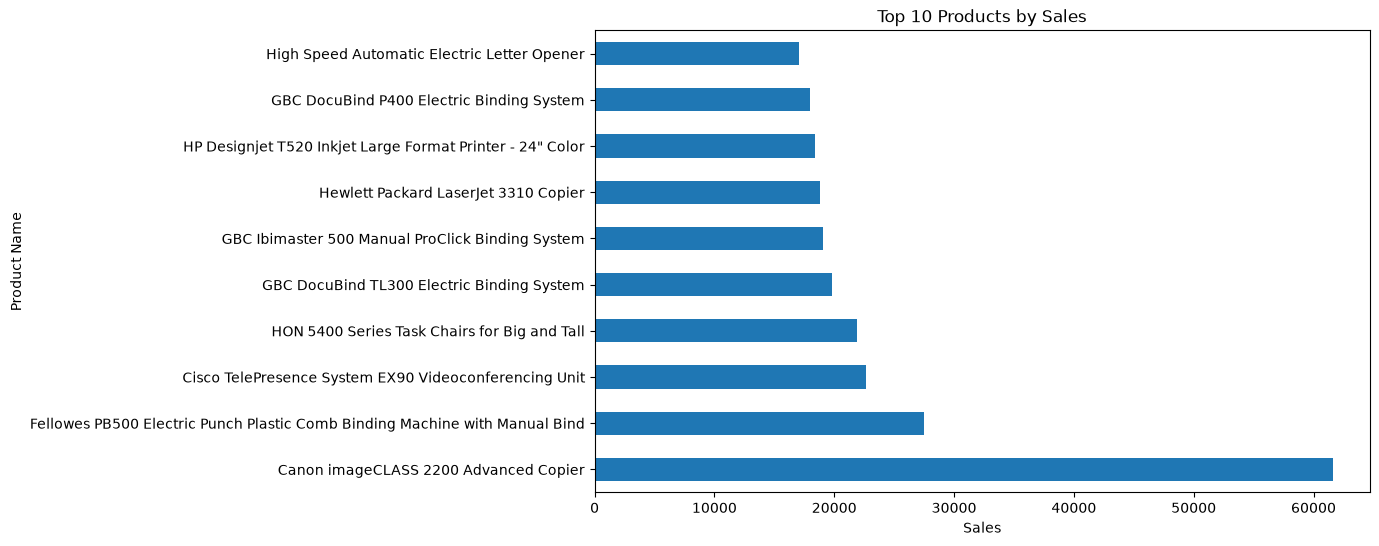

In [22]:
top_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")

plt.xlabel("Sales")

plt.show()

# Top 10 Customers

In [23]:
top_customers = (
    df.groupby("Customer Name")
      .agg(
          Total_Sales=("Sales","sum"),
          Total_Profit=("Profit","sum"),
          Orders=("Order ID","nunique")
      )
      .sort_values("Total_Sales",ascending=False)
      .head(10)
)

top_customers

,Total_Sales,Total_Profit,Orders
Customer Name,,,
Sean Miller,25043.050,-1980.7393,5
Tamara Chand,19052.218,8981.3239,5
Raymond Buch,15117.339,6976.0959,6
Tom Ashbrook,14595.620,4703.7883,4
Adrian Barton,14473.571,5444.8055,10
Ken Lonsdale,14175.229,806.8550,12
Sanjit Chand,14142.334,5757.4119,9
Hunter Lopez,12873.298,5622.4292,6
Sanjit Engle,12209.438,2650.6769,11


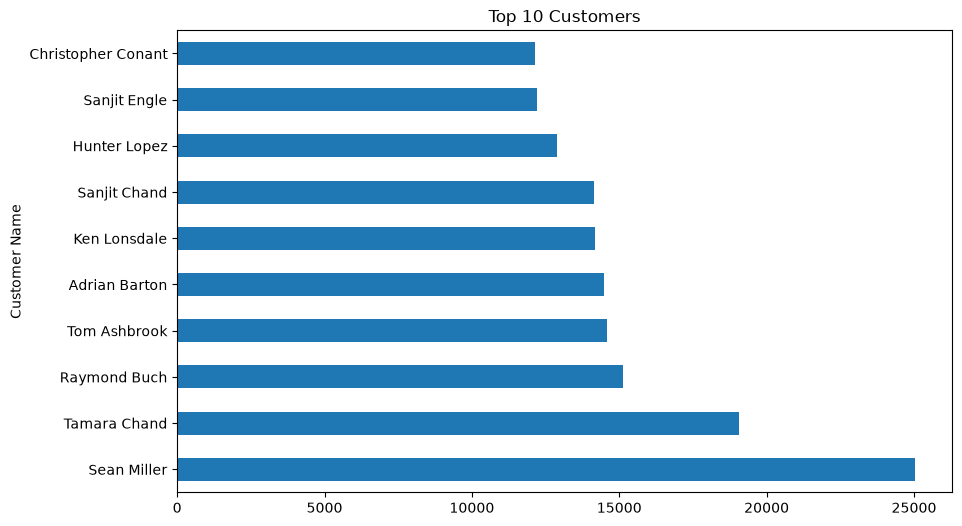

In [24]:
top_customers["Total_Sales"].plot(kind="barh")

plt.title("Top 10 Customers")

plt.show()

# Monthly Sales Trend

In [25]:
monthly_sales = (
    df.groupby(["Year","Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales[["Year","Month"]].assign(DAY=1)
)

monthly_sales.head()

,Year,Month,Sales,Date
0,2014,1,14236.895,2014-01-01
1,2014,2,4519.892,2014-02-01
2,2014,3,55691.009,2014-03-01
3,2014,4,28295.345,2014-04-01
4,2014,5,23648.287,2014-05-01


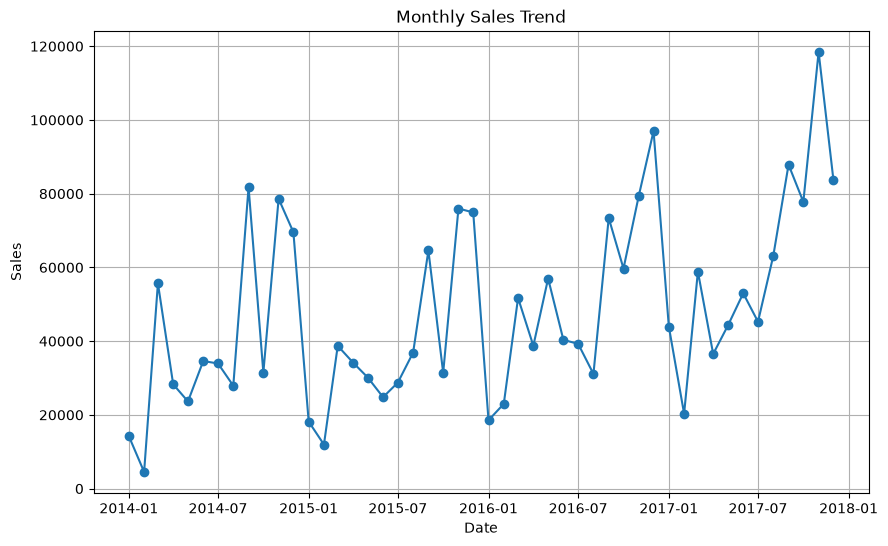

In [26]:
plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

# State-wise Sales

In [27]:
state_sales = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state_sales

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

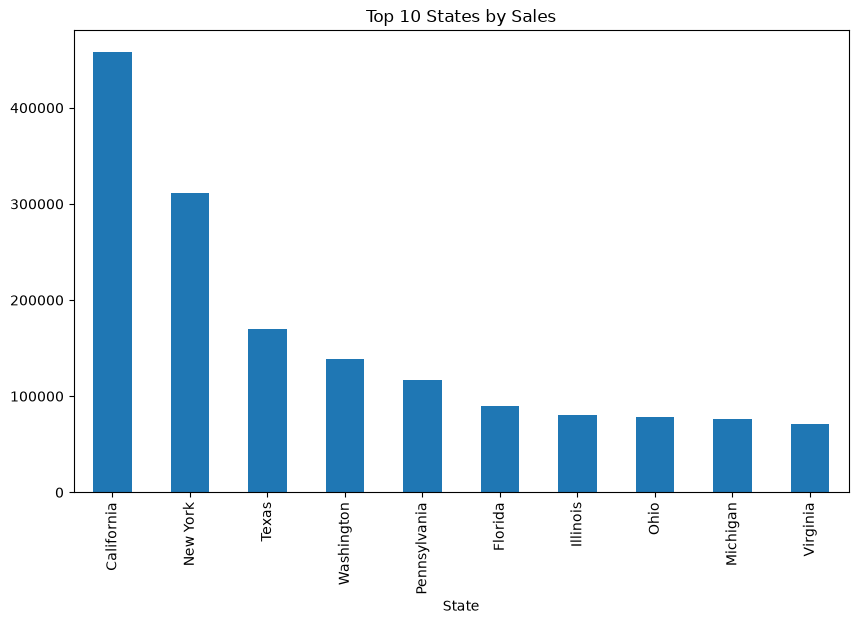

In [28]:
state_sales.plot(kind="bar")

plt.title("Top 10 States by Sales")

plt.show()

# Discount vs Profit

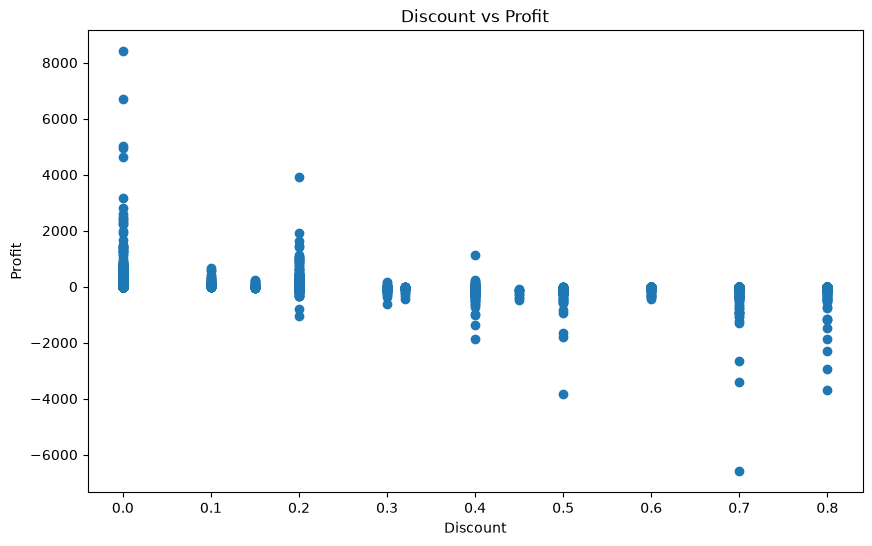

In [29]:
plt.scatter(
    df["Discount"],
    df["Profit"]
)

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()

# Correlation Analysis

In [30]:
numeric_df = df.select_dtypes(include=["number"])

numeric_df.corr()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Day,Shipping Days
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497,0.015430,-0.018732,-0.021651,0.001832,-0.001446
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961,0.004299,0.026234,0.027770,0.016840,-0.009771
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064,-0.009679,-0.000625,-0.002501,0.003150,-0.007354
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253,-0.005810,0.023355,0.026546,0.011614,0.018298
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487,-0.002662,-0.004935,-0.001620,-0.004016,0.000408
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000,0.004670,-0.000502,-0.002830,-0.002965,-0.004649
Year,0.015430,0.004299,-0.009679,-0.005810,-0.002662,0.004670,1.000000,-0.020183,-0.020005,-0.017455,-0.022736
Month,-0.018732,0.026234,-0.000625,0.023355,-0.004935,-0.000502,-0.020183,1.000000,0.969308,-0.033581,0.000810
Quarter,-0.021651,0.027770,-0.002501,0.026546,-0.001620,-0.002830,-0.020005,0.969308,1.000000,-0.025644,0.005131
Day,0.001832,0.016840,0.003150,0.011614,-0.004016,-0.002965,-0.017455,-0.033581,-0.025644,1.000000,0.015603


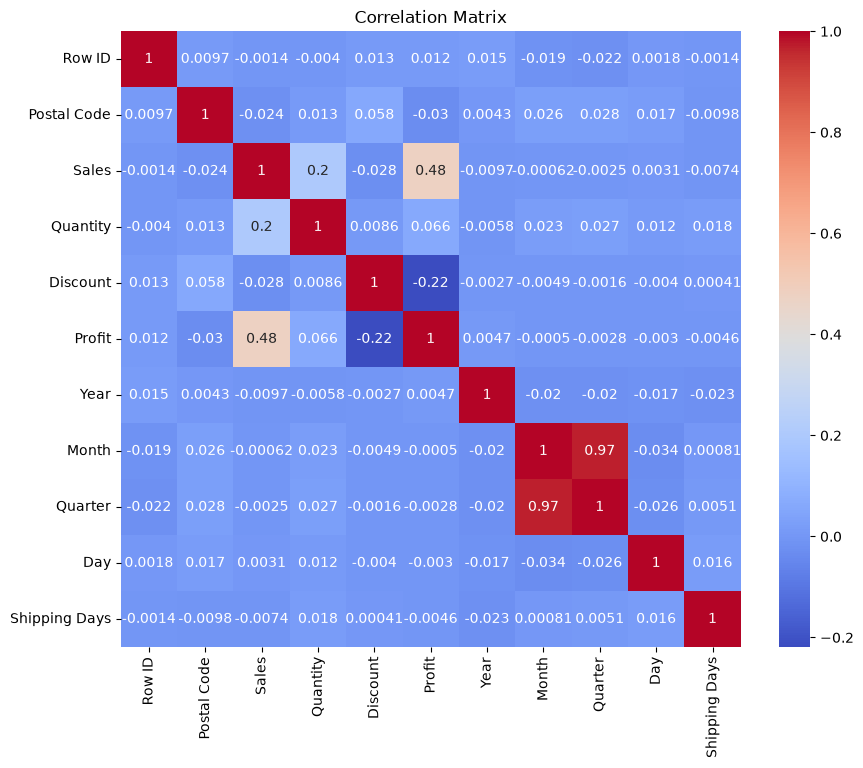

In [33]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Business Insights

## Executive Summary

- Technology generated the highest sales.
- West region contributed the highest revenue.
- Consumer segment generated the maximum sales.
- Higher discounts generally reduced profitability.
- Sales increased over the years.
- A small number of customers contributed significantly to total revenue.